# Building a training sample, step by step

This notebook builds **one** `streamgoggles` training sample two ways:

1. **Step by step** — every stage of the pipeline as its own cell, so you can
   see (and plot) what each stage actually produces: study region -> cached
   background (per named matched filter) -> realized stream -> placed in the
   footprint -> injected through the survey model -> cuts/clipping -> window
   -> per-(filter, distance) combined map + stream-only label -> `Sample`.
2. **Minimal command** — the same result via the real pipeline API
   (`StreamInjector.inject_single_stream` / `inject_background_only`), which
   is what `scripts/train.py` (or any dataset loader) actually calls.

All the tunable settings live in **one cell (§1)** as plain dictionaries —
change them and re-run from there to explore a different background source,
richness unit, filter set, pixelization, etc.

**Multiple matched filters, not one** (2026-09-09 pivot, PLAN.md §6.3): each
sample now has one channel per `(filter, distance)` pair, not one per
distance. Alongside a real isochrone filter ("good"), a deliberately "bad"
decoy filter (a plain color-magnitude box, same magnitude range, shifted off
the isochrone locus in color) still lets background contamination through
without preferring real stream stars -- pairing them teaches a network what
contamination looks like versus a real overdensity. The label for each
channel is simply that channel's own true stream-only star count (no
background mixed in), so it depends on which filter produced it: the "good"
channel's label should be well above the "decoy" channel's at the stream's
true distance.

Everything here runs against the real `streamobs`/`ugali` machinery (no
mocking), using the `light` synthetic LSST yr1 background by default so it
needs no large data files.

In [1]:
import dataclasses
import tempfile

import healpy as hp
import matplotlib.pyplot as plt
import numpy as np

from streamgoggles.background import Background
from streamgoggles.background_sources import (
    DataFileBackgroundSource,
    StreamObsCatalogueBackgroundSource,
    StreamObsLightBackgroundSource,
    StudyRegion,
)
from streamgoggles.data_preparation import Cut, apply_cuts, apply_magnitude_clipping
from streamgoggles.injector import (
    StreamInjector,
    inject_background_only,
    place_stream_in_footprint,
    resolve_richness_to_nstars,
)
from streamgoggles.matched_filter import (
    PixelizationSpec,
    ShiftedColorBoxFilter,
    StreamobsSplineFilter,
    combine_full_maps,
    crop_window,
    finalize_full,
    make_raw_map,
)
from streamgoggles.sample import Sample
from streamgoggles.storage import BackgroundMapStore
from streamgoggles.datasets.transforms import RobustNormalizer, StreamMapTransform
from streamgoggles.stream_sources import StreamObsSource
from streamgoggles.windows import sample_random_window, sample_stream_window
from streamobs.columns import flag_col
from streamobs.observed import StreamInjector as ObsStreamInjector

%matplotlib inline

## 1. Configuration — edit these, then re-run from §2 on

These mirror the shapes of `config/background.yaml`, `config/matched_filter.yaml`
and `config/streams/injection_grid.yaml` (see PLAN.md), just as plain dicts
here so you can tweak a value and immediately see its effect, without
round-tripping through YAML.

`stream_cfg["richness"]` takes exactly one of `nstars` / `mass` (Msun) /
`surface_brightness` (mag/arcsec^2) — whichever you set is converted to a
true star count by `resolve_richness_to_nstars` in §2.4 (decision 16/§4.1).

`cuts_cfg`/`clipping_cfg` are their **own** top-level dicts, not nested
inside `background_cfg` — they're shared, catalog-agnostic settings
(`data_preparation.apply_cuts`/`apply_magnitude_clipping`, decision 13),
applied identically to the background catalog (§2.3) *and* the injected
stream catalog (§2.6). Nesting them under `background_cfg` would suggest
they're background-specific, which is exactly backwards.

`filters_cfg` is an **ordered** dict: a `"shifted_box"` entry is built by
shifting off its own `reference` filter's polygon, so `reference` must
already be a key earlier in the dict. `"good"` should normally come first.

**Found while building this notebook (2026-09-09):** `config/background.yaml`'s
own default cuts (`quantity: snr`) don't actually work with its own default
`source: light` — the `light` generator doesn't produce per-star error
columns at all (only `injection`/`data_file` do), so an "snr" cut has no
column to read (`KeyError`). Fixed in `background.yaml` itself; the cuts
below use `"mag"`, which every source produces.

In [2]:
SEED = 42

study_region_cfg = dict(center_ra=0.0, center_dec=-30.0, width_deg=25.0, height_deg=18.0)

# Shared, catalog-agnostic (decision 13) -- applied identically to the
# background (§2.3) and the injected stream (§2.6), not background-specific.
cuts_cfg = [
    # "snr" cuts need per-star error columns, which only "injection"/
    # "data_file" background sources produce -- not "light" (see note above);
    # the injected stream always has them, since streamobs's own injector
    # always reports one.
    dict(quantity="mag", band="g", op="<", value=26.5),
    dict(quantity="mag", band="r", op="<", value=26.0),
]
clipping_cfg = {"g": {"min": 16.0, "max": 26.5}, "r": {"min": 16.0, "max": 26.0}}

background_cfg = dict(
    source="light",       # "data_file" | "light" | "injection"
    survey="lsst",
    release="yr1",         # "yr1" (synthetic forecast) or "dp2" (real skim, data_file only)
    source_kwargs={},      # extra kwargs for the chosen BackgroundSource.load()
    finalize={"enabled": False},  # background-subtraction not implemented yet (matched_filter.finalize_full)
)

# Named matched filters (2026-09-09 pivot, PLAN.md §6.3) -- one channel per
# (filter, distance) pair. "decoy" is a plain color-magnitude box, same
# magnitude range as "good" at each distance, shifted off the isochrone
# locus in color -- still lets background contamination through, without
# preferring real stream stars.
filters_cfg = dict(
    good=dict(type="isochrone", reference_isochrone=dict(age=12.5, z=0.0002)),
    decoy=dict(type="shifted_box", reference="good", color_shift=0.5, color_width=0.3),
)

matched_filter_cfg = dict(
    bands=["g", "r"],
    pixelization=dict(nside=64, image_size_pix=(41, 41), pixel_scale_deg=1.0),
    distance_moduli=[16.0, 16.8],  # trial distances scanned; 16.8 matches the stream below
)

stream_cfg = dict(
    morphology="uniform",       # "uniform" | "spline" (decision 5)
    richness={"nstars": 3000},  # or {"mass": 5000.0} or {"surface_brightness": 30.0}
    width=0.2,
    length=8.0,
    distance_modulus=16.8,
    age=12.5,
    z=0.0002,
)

window_cfg = dict(min_stream_length_deg=5.0, max_attempts=100)  # decision 21

namespace = f"{background_cfg['survey']}_{background_cfg['release']}"
rng = np.random.default_rng(SEED)

## 2. Step by step

### 2.1 Study region — where synthetic background may be generated at all

A plain RA/Dec box (decision 24), independent of and larger than any one
sample's window.

In [3]:
study_region = StudyRegion(**study_region_cfg)
study_region

StudyRegion(center_ra=0.0, center_dec=-30.0, width_deg=25.0, height_deg=18.0)

### 2.2 Pixelization and matched filters

`PixelizationSpec` fixes the HEALPix `nside` (and auto-derives `pixel_scale_deg`
if you don't set one — see `matched_filter_demo.ipynb` for that in detail).
Each matched filter is a hard color-magnitude cut: `"good"` around a
reference isochrone (age, metallicity), `"decoy"` a plain box shifted off it
in color, sharing `"good"`'s magnitude range at each trial distance.

In [4]:
pix = PixelizationSpec(**matched_filter_cfg["pixelization"])

matched_filters = {}
for name, cfg in filters_cfg.items():
    if cfg["type"] == "isochrone":
        matched_filters[name] = StreamobsSplineFilter(
            iso_config=cfg["reference_isochrone"], namespace=namespace
        )
    elif cfg["type"] == "shifted_box":
        matched_filters[name] = ShiftedColorBoxFilter(
            reference_filter=matched_filters[cfg["reference"]],
            color_shift=cfg["color_shift"],
            color_width=cfg["color_width"],
        )
    else:
        raise ValueError(f"unknown filter type {cfg['type']!r}")

matched_filters

{'good': <streamgoggles.matched_filter.StreamobsSplineFilter at 0x107d9d070>,
 'decoy': <streamgoggles.matched_filter.ShiftedColorBoxFilter at 0x12ed33b30>}

### 2.3 Background: load, cut, clip, cache the raw maps (per filter)

`Background.load_or_cache` does four things in one call: pick the
`BackgroundSource` for `background_cfg["source"]`, load its catalog
(restricted to `study_region` for the synthetic sources), apply the *same*
cuts/clipping the stream will get in §2.6, and — for every `(filter,
distance)` pair — run that filter **once** and cache the resulting raw
HEALPix count map (`BackgroundMapStore`, here a throwaway temp directory so
this demo never touches `data/background_maps/`).

This is the *only* place any matched filter ever touches the background —
every stream injected below (however many) reuses these cached maps rather
than re-running `select()` on the background catalog.

In [5]:
source_classes = {
    "data_file": DataFileBackgroundSource,
    "light": StreamObsLightBackgroundSource,
    "injection": StreamObsCatalogueBackgroundSource,
}
background_source = source_classes[background_cfg["source"]]()
cuts = [Cut(**c) for c in cuts_cfg]

store = BackgroundMapStore(tempfile.mkdtemp(prefix="streamgoggles_demo_bgmaps_"))

background = Background.load_or_cache(
    source=background_source,
    source_cfg=background_cfg["source_kwargs"],
    study_region=study_region,
    cuts=cuts,
    clipping=clipping_cfg,
    matched_filters=matched_filters,
    bands=matched_filter_cfg["bands"],
    distance_moduli=matched_filter_cfg["distance_moduli"],
    finalize_cfg=background_cfg["finalize"],
    store=store,
    pix=pix,
    survey=background_cfg["survey"],
    release=background_cfg["release"],
    filter_configs=filters_cfg,
)
print(f"background catalog: {len(background.catalog)} stars (after cuts+clipping)")
print(f"footprint: {background.footprint.sum()} / {len(background.footprint)} HEALPix pixels valid")
print(f"cached filters: {list(background.raw_map_full_dict)}")

Loading survey data for 'lsst_yr1'...
  Loading config from: lsst_yr1.yaml

LOADING SURVEY DATA FILES
Survey data directory: /Users/pelissier/Documents/Codes/packages/streamobs/streamobs/../data/surveys/lsst_yr1

Fallback directory for shared data files: /Users/pelissier/Documents/Codes/packages/streamobs/streamobs/../data/others

Available bands: g, i, r, u, y, z


Loading survey properties...
Loading magnitude limit maps...
  ✓ Success for g-band magnitude limit
  ⚠ Warning: 'maglim_map_i' not specified in config (skipping i-band)
  ✓ Success for r-band magnitude limit
  ⚠ Warning: 'maglim_map_u' not specified in config (skipping u-band)
  ⚠ Warning: 'maglim_map_y' not specified in config (skipping y-band)
  ⚠ Warning: 'maglim_map_z' not specified in config (skipping z-band)

Loading completeness/efficiency function...
  Loading Completeness/efficiency function...
    File: lsst_dc2_stellar_efficiency_cutr.csv
    ✓ Success
  Loading Detection efficiency function...
    File: lsst_dc

/Users/pelissier/Documents/Codes/packages/streamobs/streamobs/background/background.py:159: UserWarning: Requested nside=4096 exceeds the magnitude-limit map resolution (nside=128). Capping to nside=128.
  return gen.generate(


background catalog: 6399972 stars (after cuts+clipping)
footprint: 600 / 49152 HEALPix pixels valid
cached filters: ['good', 'decoy']


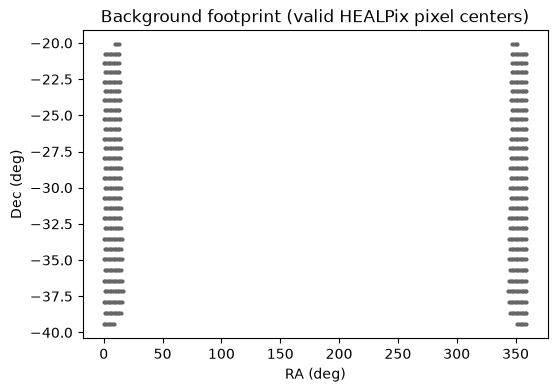

In [6]:
fp_ra, fp_dec = hp.pix2ang(pix.nside, np.flatnonzero(background.footprint), lonlat=True)
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(fp_ra, fp_dec, s=4, color="0.4")
ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title("Background footprint (valid HEALPix pixel centers)")
plt.show()

### 2.4 Realize the stream — richness resolved to a true star count

`resolve_richness_to_nstars` converts whichever unit `stream_cfg["richness"]`
is expressed in (nstars / mass / surface_brightness) to an integer `nstars`,
using `inject_utils`'s conversions. The stream is then realized in its own
`phi1`/`phi2` frame with TRUE (noiseless) magnitudes — nothing about the sky
or survey yet.

In [7]:
richness_kind, richness_value = next(iter(stream_cfg["richness"].items()))
stream_params = {k: v for k, v in stream_cfg.items() if k != "richness"}
stream_params["richness"] = richness_value
stream_params = resolve_richness_to_nstars(stream_params, richness_kind)
print(f"richness_kind={richness_kind!r}, value={richness_value} -> nstars={stream_params['nstars']}")

stream_df = StreamObsSource().realize(stream_params, rng)
stream_df.head()

richness_kind='nstars', value=3000 -> nstars=3000


,phi1,phi2,dist,is_stream,lsst_g_true,lsst_r_true
0,2.191648,0.211277,16.8,True,27.025410,26.065744
1,-0.488972,-0.151044,16.8,True,28.441676,27.318903
2,2.868783,-0.547907,16.8,True,30.836319,29.309884
3,1.578944,-0.353392,16.8,True,25.135280,24.426211
4,-3.246581,0.284325,16.8,True,29.642366,28.292827


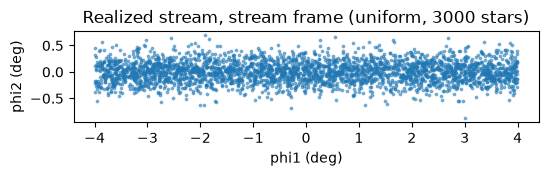

In [8]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.scatter(stream_df["phi1"], stream_df["phi2"], s=3, alpha=0.5)
ax.set_xlabel("phi1 (deg)")
ax.set_ylabel("phi2 (deg)")
ax.set_title(f"Realized stream, stream frame ({stream_params['morphology']}, {len(stream_df)} stars)")
ax.set_aspect("equal")
plt.show()

### 2.5 Place the stream in the footprint

Picks a random valid footprint pixel + random position angle and builds a
great-circle frame there (decision: not streamobs's own `_find_gc_frame`
rejection search, which fails against a footprint this narrow — see
`injector.py`'s `place_stream_in_footprint` docstring), giving every star a
real `ra`/`dec`.

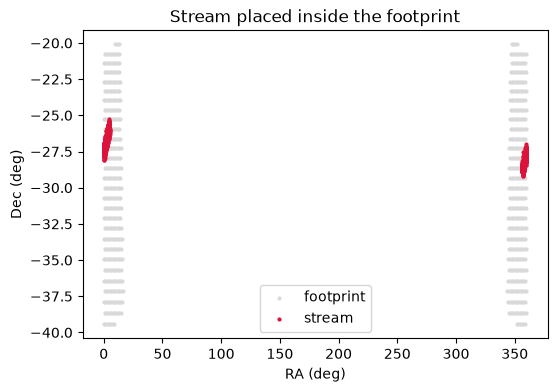

In [9]:
placed_df = place_stream_in_footprint(stream_df, background.footprint, pix.nside, rng)

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(fp_ra, fp_dec, s=4, color="0.85", label="footprint")
ax.scatter(placed_df["ra"], placed_df["dec"], s=4, color="crimson", label="stream")
ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.legend()
ax.set_title("Stream placed inside the footprint")
plt.show()

### 2.6 Inject through the survey model, then apply the same cuts/clipping as the background

`streamobs.observed.StreamInjector.inject()` adds observed (noisy)
magnitudes, reported errors, and a detection flag — using the *same*
`ra`/`dec` already set in §2.5, since it only fills in columns that are
missing. Undetected stars carry a `"BAD_MAG"` sentinel instead of a number,
so they're filtered out (via the detection flag) before anything downstream
touches those columns numerically. What's left then gets the *identical*
`apply_cuts`/`apply_magnitude_clipping` calls the background got in §2.3
(decision 13) — same function, same config, so selection is consistent
regardless of whether a star is real background or injected stream.

In [10]:
obs_injector = ObsStreamInjector(background_cfg["survey"], release=background_cfg["release"])
injected_df = obs_injector.inject(
    placed_df, bands=matched_filter_cfg["bands"], rng=rng, verbose=False
)
detected = injected_df[injected_df[flag_col(namespace)]].reset_index(drop=True)
print(f"{len(detected)} / {len(injected_df)} stream stars detected by the survey model")

detected = apply_cuts(detected, cuts, namespace=namespace, verbose=False)
if clipping_cfg:
    detected = apply_magnitude_clipping(detected, clipping_cfg, namespace=namespace)
print(f"{len(detected)} stream stars remain after cuts + magnitude clipping")
detected.head()

✓ Using cached survey data for 'lsst_yr1'
334 / 3000 stream stars detected by the survey model
334 stream stars remain after cuts + magnitude clipping


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


,phi1,phi2,dist,is_stream,lsst_g_true,lsst_r_true,ra,dec,lsst_yr1_g_obs,lsst_yr1_g_err,lsst_yr1_r_obs,lsst_yr1_r_err,lsst_yr1_flag_observed
0,1.578944,-0.353392,16.8,True,25.135280,24.426211,358.904130,-27.539305,25.459776,0.185782,24.371093,0.069976,True
1,2.621049,0.150972,16.8,True,22.095767,21.823240,358.011016,-28.386716,22.100794,0.011005,21.80722,0.007701,True
2,-3.649570,-0.253818,16.8,True,25.456460,24.698437,4.341870,-25.614805,25.375789,0.207667,24.627858,0.112536,True
3,1.958097,-0.147255,16.8,True,21.728832,21.486892,358.590104,-27.869379,21.749002,0.009970,21.49086,0.006802,True
4,1.602121,0.063600,16.8,True,25.016720,24.325747,359.052187,-27.935849,25.375973,0.188147,24.302941,0.057533,True


### 2.7 Sample a window

Rejection-samples a window (same pixel size as `pix`) with >= 5 deg of
stream track inside it (decision 21) — a floor, not a guarantee of full
inclusion.

In [11]:
size_deg = pix.image_size_pix[0] * pix.pixel_scale_deg
window = sample_stream_window(
    detected["ra"].to_numpy(dtype=float),
    detected["dec"].to_numpy(dtype=float),
    stream_params.get("width", 0.0),
    background.footprint,
    pix.nside,
    size_deg=size_deg,
    min_stream_length_deg=window_cfg["min_stream_length_deg"],
    max_attempts=window_cfg["max_attempts"],
    rng=rng,
)
window

Window(center_ra=355.46731368128553, center_dec=-36.665275907898724, rotation_deg=200.39010223744367, width_deg=41.0, height_deg=41.0)

### 2.8 Per (filter, distance) channel: select, combine, finalize, crop -- and the label

For each trial distance, for each named filter: that filter selects which
stream stars are color-magnitude-consistent with *that* channel, those get
their own raw HEALPix count map (this is *also* the label -- the true
stream-only count, no background mixed in, no separate rasterize.py step
needed, 2026-09-09 pivot). It's added to that filter's own cached background
map (§2.3), optionally finalized (identity here — background subtraction
isn't implemented yet, decision 18 default off), and cropped/projected to
the window. Channels are ordered distance-major, filter-minor -- the same
order `Sample.metadata["channels"]` records.

In [12]:
channels_meta = []
bg_channels, label_channels, combined_channels = [], [], []
valid_mask = None

for dm in matched_filter_cfg["distance_moduli"]:
    for filter_name, mf in matched_filters.items():
        selected = mf.select(detected, matched_filter_cfg["bands"], dm)
        stream_raw, _ = make_raw_map(detected, selected, pix)
        bg_raw = background.raw_map_full_dict[filter_name][dm]
        combined_raw = combine_full_maps(bg_raw, stream_raw, background.valid_mask_full)
        finalized = finalize_full(combined_raw, background.valid_mask_full, background_cfg["finalize"])

        windowed_bg, _ = crop_window(bg_raw, background.valid_mask_full, window, pix)
        windowed_label, _ = crop_window(stream_raw, background.valid_mask_full, window, pix)
        windowed_combined, windowed_valid = crop_window(finalized, background.valid_mask_full, window, pix)

        bg_channels.append(windowed_bg)
        label_channels.append(windowed_label)
        combined_channels.append(windowed_combined)
        if valid_mask is None:
            valid_mask = windowed_valid
        channels_meta.append({"filter": filter_name, "distance_modulus": dm})

map_stack = np.stack(combined_channels, axis=0).astype(np.float32)
label_stack = np.stack(label_channels, axis=0).astype(np.float32)
print(f"map_stack shape: {map_stack.shape} (n_dist * n_filters, ny, nx)")
print(f"label sum per channel: {label_stack.sum(axis=(1, 2))}")

map_stack shape: (4, 41, 41) (n_dist * n_filters, ny, nx)
label sum per channel: [ 77.155365  23.164814 232.93774   31.883541]


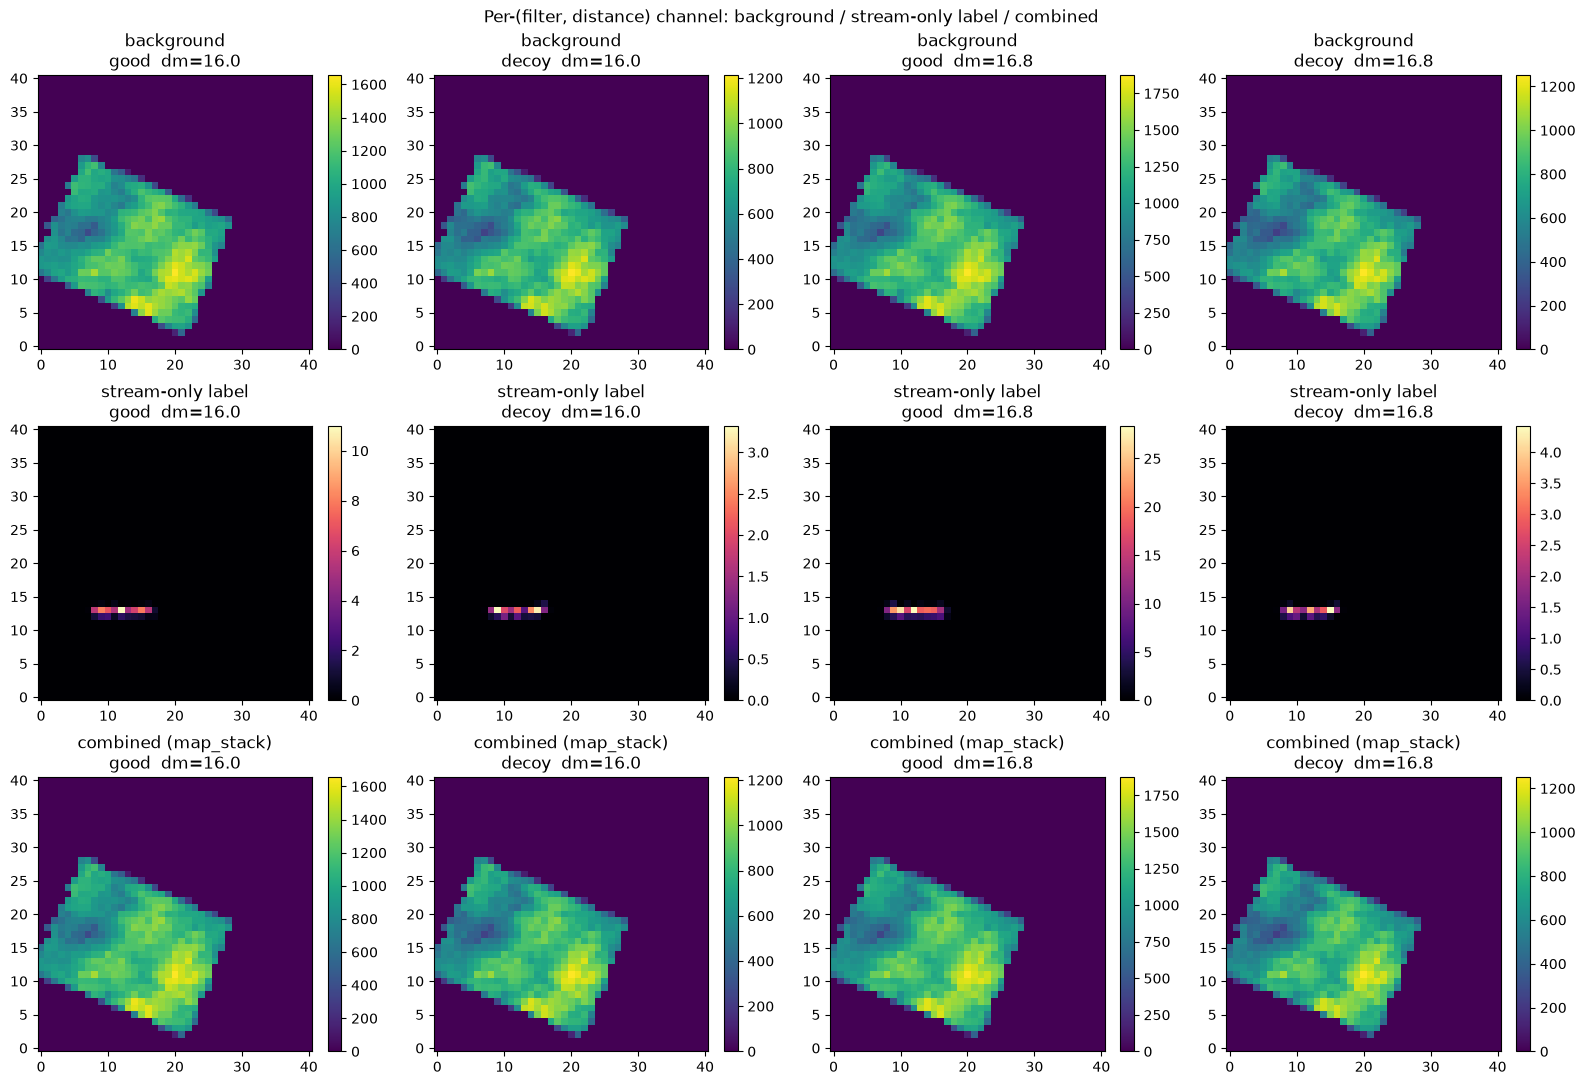

In [13]:
n_cols = len(channels_meta)
fig, axes = plt.subplots(3, n_cols, figsize=(4 * n_cols, 11), squeeze=False)
row_specs = [
    (bg_channels, "background", "viridis"),
    (label_channels, "stream-only label", "magma"),
    (combined_channels, "combined (map_stack)", "viridis"),
]
for j, meta in enumerate(channels_meta):
    for i, (channels, row_label, cmap) in enumerate(row_specs):
        ax = axes[i, j]
        im = ax.imshow(channels[j], origin="lower", cmap=cmap)
        ax.set_title(f"{row_label}\n{meta['filter']}  dm={meta['distance_modulus']}")
        plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Per-(filter, distance) channel: background / stream-only label / combined")
plt.tight_layout()
plt.show()

### 2.9 Assemble the `Sample`

Bundles everything `storage.SimulationStore` would persist. `channels`
records the exact `(filter, distance)` meaning of every `map_stack`/
`label_stack` index.

In [14]:
sample_manual = Sample(
    map_stack=map_stack,
    label_stack=label_stack,
    valid_mask=valid_mask,
    params=stream_params,
    metadata={
        "window": dataclasses.asdict(window),
        "distance_moduli": matched_filter_cfg["distance_moduli"],
        "channels": channels_meta,
    },
)
sample_manual

Sample(map_stack=array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0.

## 3. The same thing, minimal command

Everything in §2.4-2.9 is exactly what `StreamInjector.inject_single_stream`
does internally, given the same `background`/`matched_filters` built in
§2.2-2.3 (reused here, not rebuilt — matched filters must still only ever
touch the background once). One call, one `Sample`, `label_policy` defaults
to `"stream_count"` (the mechanism from §2.8).

In [15]:
injector = StreamInjector(
    background=background,
    matched_filters=matched_filters,
    stream_source=StreamObsSource(),
    cuts=cuts,
    clipping=clipping_cfg,
    pix=pix,
    survey=background_cfg["survey"],
    release=background_cfg["release"],
    bands=tuple(matched_filter_cfg["bands"]),
    richness_kind=richness_kind,
    finalize_cfg=background_cfg["finalize"],
)

stream_params_raw = {k: v for k, v in stream_cfg.items() if k != "richness"}
stream_params_raw["richness"] = richness_value

sample_minimal = injector.inject_single_stream(stream_params_raw, np.random.default_rng(SEED))
sample_minimal

✓ Using cached survey data for 'lsst_yr1'


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Sample(map_stack=array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0.

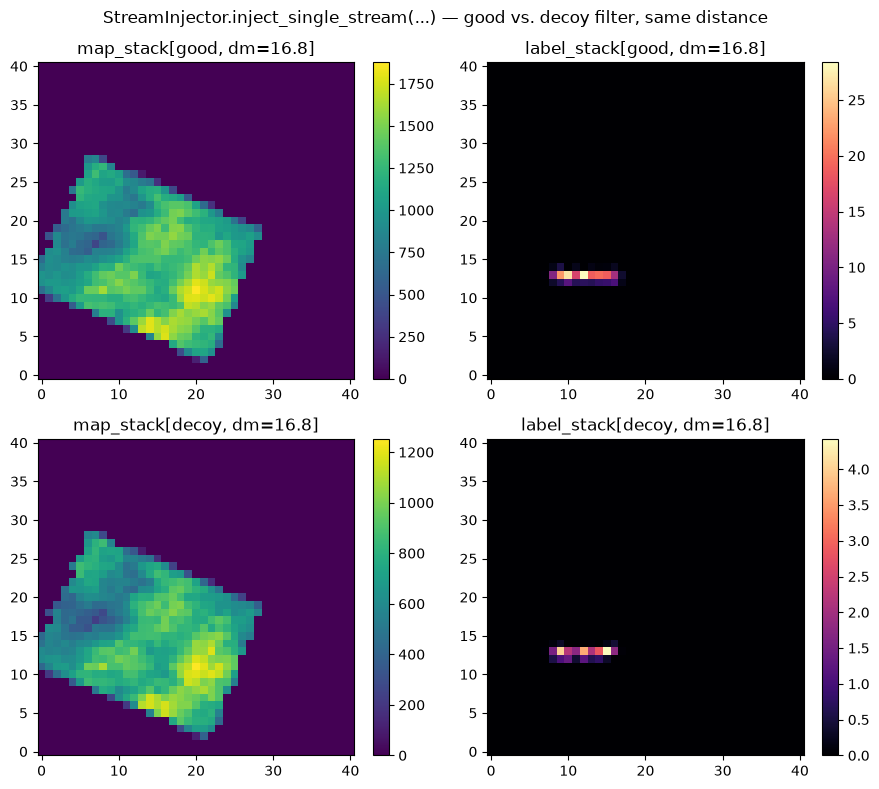

label sum, good: 232.93774
label sum, decoy: 31.883541


In [16]:
# Pick whichever trial distance is closest to the stream's own true
# distance_modulus, from matched_filter_cfg -- not a hardcoded value, so
# this stays correct if either config dict above changes.
channels_minimal = sample_minimal.metadata["channels"]
closest_dm = min(
    matched_filter_cfg["distance_moduli"],
    key=lambda d: abs(d - stream_cfg["distance_modulus"]),
)
good_idx = channels_minimal.index({"filter": "good", "distance_modulus": closest_dm})
decoy_idx = channels_minimal.index({"filter": "decoy", "distance_modulus": closest_dm})

fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for row, (name, idx) in enumerate([("good", good_idx), ("decoy", decoy_idx)]):
    im0 = axes[row, 0].imshow(sample_minimal.map_stack[idx], origin="lower", cmap="viridis")
    axes[row, 0].set_title(f"map_stack[{name}, dm={closest_dm}]")
    plt.colorbar(im0, ax=axes[row, 0], fraction=0.046)
    im1 = axes[row, 1].imshow(sample_minimal.label_stack[idx], origin="lower", cmap="magma")
    axes[row, 1].set_title(f"label_stack[{name}, dm={closest_dm}]")
    plt.colorbar(im1, ax=axes[row, 1], fraction=0.046)
fig.suptitle("StreamInjector.inject_single_stream(...) — good vs. decoy filter, same distance")
plt.tight_layout()
plt.show()

print("label sum, good:", sample_minimal.label_stack[good_idx].sum())
print("label sum, decoy:", sample_minimal.label_stack[decoy_idx].sum())

### 3.1 Pure background (no stream)

For `background_fraction > 0` (decision 20) — no realization, no injection,
no label computation, just the cached background cropped to a randomly
placed window, one channel per `(filter, distance)` pair exactly as
`inject_single_stream` produces (so background-only and stream samples stay
shape-compatible).

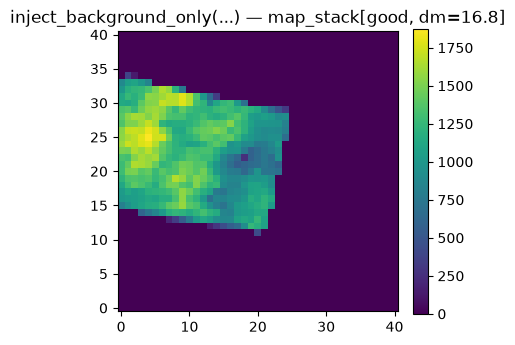

label_stack is all zero: True
params: {}


In [17]:
window_bg_only = sample_random_window(
    background.footprint, pix.nside, size_deg=size_deg, rng=np.random.default_rng(SEED + 1)
)
sample_bg_only = inject_background_only(background, window_bg_only, pix)

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(sample_bg_only.map_stack[good_idx], origin="lower", cmap="viridis")
ax.set_title(f"inject_background_only(...) — map_stack[good, dm={closest_dm}]")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.show()

print("label_stack is all zero:", bool(np.all(sample_bg_only.label_stack == 0.0)))
print("params:", sample_bg_only.params)

### 3.2 Final preparation: what the model actually sees

`inject_single_stream`'s `map_stack`/`label_stack` are the *physical*
quantities (counts), not what `models.unet.UNet` is actually fed --
training additionally normalizes `map_stack` per channel
(`datasets.transforms.RobustNormalizer`, fit on valid pixels only) and
leaves `label_stack` in raw counts (see `PLAN.md`/the docs' "Datasets and
models" page for why). This step reproduces that exact preparation on
`sample_minimal` and plots the true model input side by side with the raw
map, **explicitly masking invalid pixels** (`np.where(valid_mask, x,
np.nan)` + `cmap.set_bad`) rather than leaving them at their raw `0.0` fill
value blended in among the normalized data -- the trap documented in the
"Datasets and models" guide page: a raw `0.0` sitting inside an otherwise
mean-0/std-1 normalized channel can look like an unremarkable value rather
than the sentinel it is, unless you check `valid_mask` explicitly.


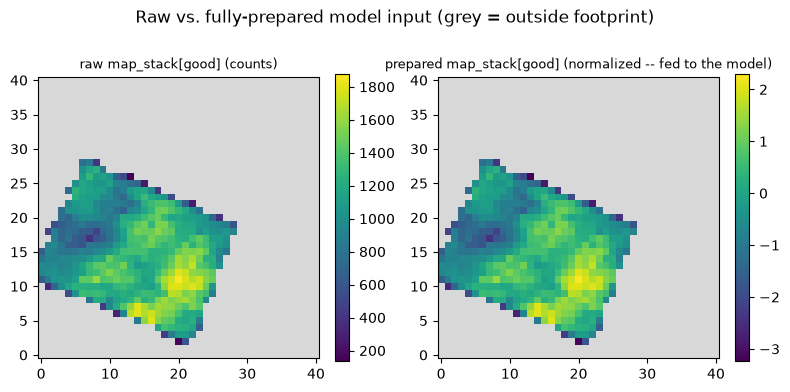

per-channel normalizer mean: [1043.22045898  732.35900879 1154.58630371  737.58563232]
per-channel normalizer std:  [268.77294922 205.80528259 314.87133789 215.5867157 ]
invalid pixels stay at their raw fill value after normalization: True


In [18]:
# A single sample's own valid pixels are enough to fit() here -- this
# notebook only wants to show what preparation *does*, not produce
# well-calibrated statistics (train_model.ipynb pools several samples
# instead, which is what a real training run should do).
normalizer = RobustNormalizer()
normalizer.fit(sample_minimal.map_stack, sample_minimal.valid_mask)

transform = StreamMapTransform(normalizer=normalizer, augment=False)
prepared = transform(
    {
        "map_stack": sample_minimal.map_stack,
        "label_stack": sample_minimal.label_stack,
        "valid_mask": sample_minimal.valid_mask,
        "params": sample_minimal.params,
        "metadata": sample_minimal.metadata,
    }
)

cmap = plt.get_cmap("viridis").copy()
cmap.set_bad(color="0.85")


def _masked(img, valid_mask):
    return np.where(valid_mask, img, np.nan)


fig, axes = plt.subplots(1, 2, figsize=(8, 4))
im0 = axes[0].imshow(
    _masked(sample_minimal.map_stack[good_idx], sample_minimal.valid_mask),
    origin="lower",
    cmap=cmap,
)
axes[0].set_title("raw map_stack[good] (counts)", fontsize=9)
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(
    _masked(prepared["map_stack"][good_idx], prepared["valid_mask"]), origin="lower", cmap=cmap
)
axes[1].set_title("prepared map_stack[good] (normalized -- fed to the model)", fontsize=9)
plt.colorbar(im1, ax=axes[1], fraction=0.046)

fig.suptitle("Raw vs. fully-prepared model input (grey = outside footprint)")
plt.tight_layout()
plt.show()

print(f"per-channel normalizer mean: {normalizer.mean}")
print(f"per-channel normalizer std:  {normalizer.std}")
print(
    "invalid pixels stay at their raw fill value after normalization:",
    bool(
        np.all(
            prepared["map_stack"][:, ~prepared["valid_mask"]]
            == sample_minimal.map_stack[:, ~sample_minimal.valid_mask]
        )
    ),
)


## Summary

| Step-by-step (§2) | Minimal command (§3) |
|---|---|
| §2.4 `resolve_richness_to_nstars` + `StreamObsSource.realize` | `StreamInjector.inject_single_stream` step 1 |
| §2.5 `place_stream_in_footprint` | step 2 |
| §2.6 `ObsStreamInjector.inject` + `flag_col` filter + `apply_cuts`/`apply_magnitude_clipping` | steps 3-4 |
| §2.7 `sample_stream_window` | step 2 (window depends on placement, so it's sampled together with it) |
| §2.8 per (filter, distance): `select` + `make_raw_map` (also the label) + `combine_full_maps` + `finalize_full` + `crop_window` | steps 5-7 |
| §2.9 `Sample(...)` | step 8 |

`Background.load_or_cache` (§2.3) is built once, outside the injector, and
handed in — that's what makes "every matched filter only ever touches the
background once, no matter how many streams get injected" true (verified in
`tests/test_injector.py::test_inject_single_stream_reuses_background_selection_across_injections`).

The "good" filter's label consistently beats the "decoy" filter's at the
stream's true distance (`tests/test_injector.py::test_inject_single_stream_good_filter_label_beats_decoy_at_true_distance`)
— exactly the signal a background-cleaning network needs to learn from
(PLAN.md §6.3).